In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the House Price dataset

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# Basic dataset search

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (506, 14)

Column Names:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Data Types:
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Duplicate Rows: 0


In [4]:
# Descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


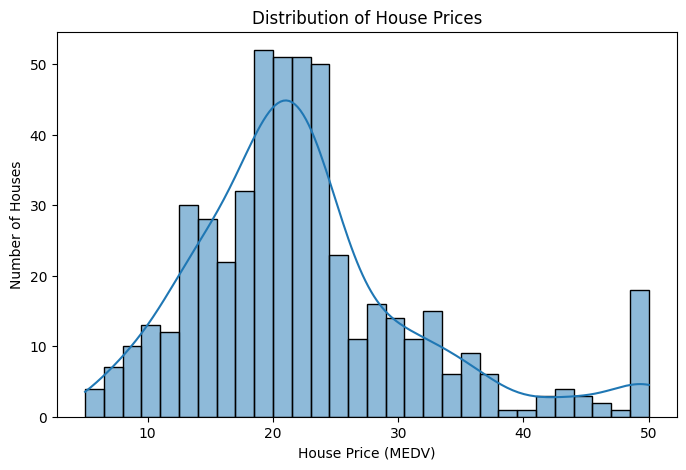

In [5]:
# Checking how the house prices are distributed

plt.figure(figsize=(8, 5))
sns.histplot(df["medv"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (MEDV)")
plt.ylabel("Number of Houses")

plt.show()

In [6]:
# Looking at which features may affect house prices

correlation_with_price = df.corr()["medv"].sort_values(ascending=False)

print("Correlation of features with house price:")
print(correlation_with_price)

Correlation of features with house price:
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


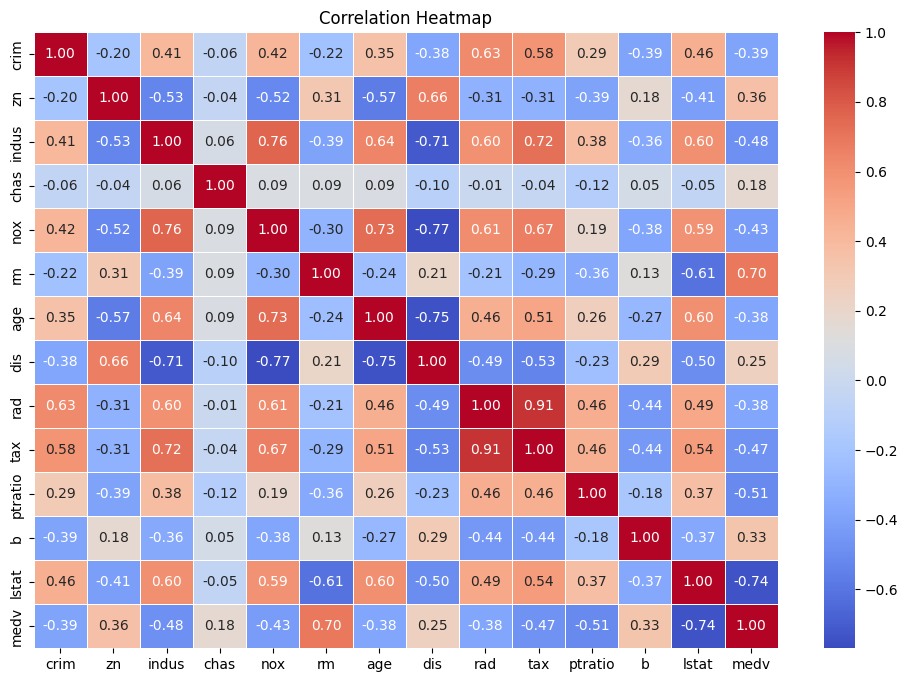

In [7]:
# Checking the relationship between the different features

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Separating the input features from the house price

X = df.drop("medv", axis=1)
y = df["medv"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (506, 13)
Target shape: (506,)


In [9]:
# Splitting the data into training and testing parts

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 13)
Testing data: (102, 13)


In [10]:
# Building the linear regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [11]:
# Predicting house prices using the trained model

y_pred = model.predict(X_test)

print("Predictions created successfully!")
print("First 10 predicted prices:")
print(y_pred[:10])

Predictions created successfully!
First 10 predicted prices:
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597]


In [12]:
# Checking how well the model performed

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 2))

Mean Squared Error (MSE): 24.29
Root Mean Squared Error (RMSE): 4.93
R² Score: 0.67


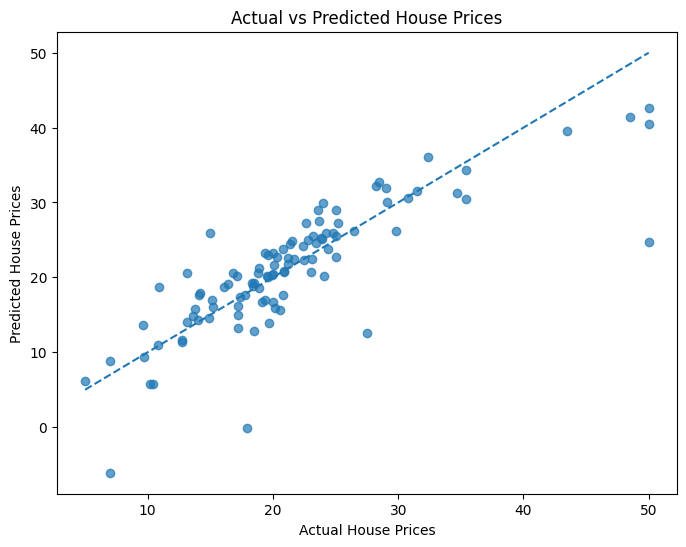

In [13]:
# Comparing actual prices with predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

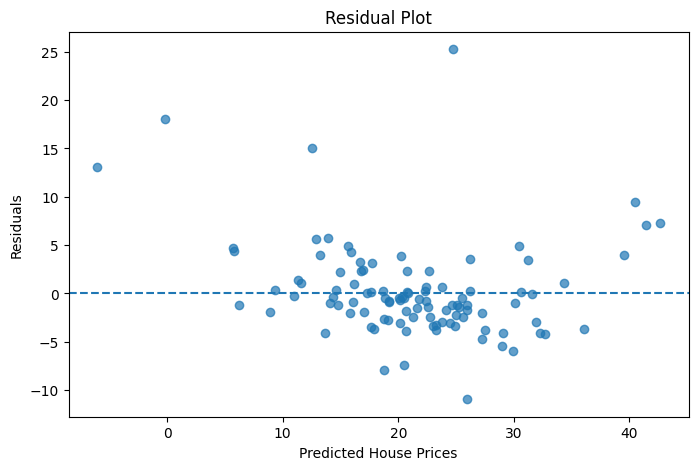

In [14]:
# Checking the prediction errors

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [15]:
# Checking how each feature affects the prediction

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute Value"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute Value", ascending=False)

coefficients

,Feature,Coefficient,Absolute Value
4,nox,-17.202633,17.202633
5,rm,4.438835,4.438835
3,chas,2.784438,2.784438
7,dis,-1.447865,1.447865
10,ptratio,-0.915456,0.915456
12,lstat,-0.508571,0.508571
8,rad,0.262430,0.262430
0,crim,-0.113056,0.113056
2,indus,0.040381,0.040381
1,zn,0.030110,0.030110


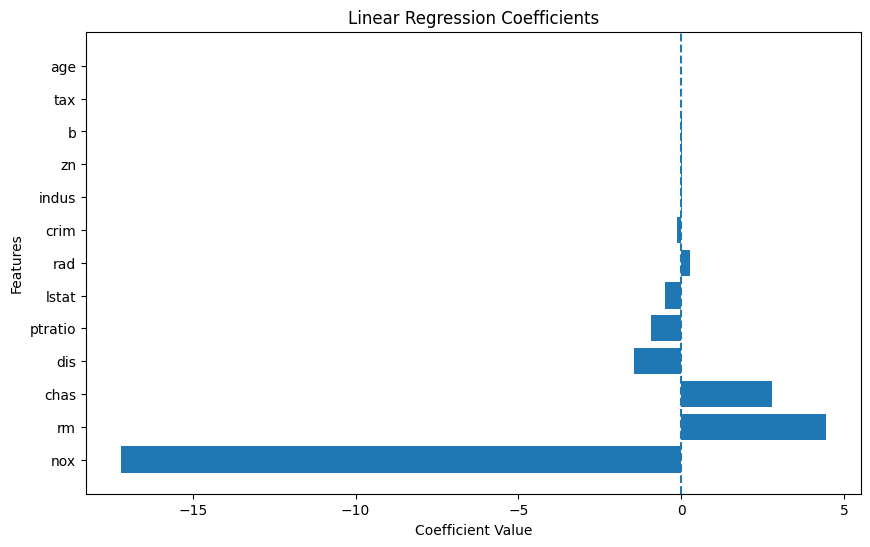

In [16]:
# Visualising the model coefficients

plt.figure(figsize=(10, 6))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Linear Regression Coefficients")

plt.axvline(0, linestyle="--")
plt.show()

### Feature Selection

I checked the correlation of the features with the house price (`medv`) before building the model. The `rm` feature showed a strong positive relationship with house price, while `lstat` showed a strong negative relationship. Other features such as `ptratio`, `indus`, and `tax` also showed noticeable relationships with the target.

I kept all the available numerical features for the Linear Regression model so that the model could use the information from the complete dataset.

### Data Preparation

The dataset did not have any missing values, so no missing-value treatment was needed.

All the predictor columns in this dataset are numerical. Because there were no categorical columns, One-Hot Encoding was not required for this dataset.

### Conclusion

The Linear Regression model was able to predict house prices using the available features.

The model achieved an R² score of 0.67, with an RMSE of 4.93. The actual vs predicted plot shows that many predictions are reasonably close to the actual values, although some larger differences can be seen.

The correlation analysis showed that `rm` had a positive relationship with house prices, while `lstat` had a negative relationship. The coefficient analysis also showed that different features had different effects on the predicted price.

Overall, this project helped me understand the complete process of preparing data, exploring features, training a Linear Regression model, evaluating its performance, and interpreting the results.